<a href="https://colab.research.google.com/github/untungbensugih/Tugas_Machine_Learning/blob/main/Tugas_2_Untung_Sugiono.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Untung Sugiono (052713741)

--- Atribut Data Periode 1 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   1827 non-null   int64  
 1   Status Pernikahan                    1827 non-null   object 
 2   Program Studi                        1827 non-null   object 
 3   Kelas Reguler/Malam                  1824 non-null   object 
 4   Pendidikan Terakhir                  1827 non-null   object 
 5   Nilai SMA                            1827 non-null   float64
 6   Daerah Asal                          1824 non-null   object 
 7   Pendidikan Ibu                       1827 non-null   object 
 8   Pendidikan Ayah                      1827 non-null   object 
 9   Pekerjaan Ibu                        1827 non-null   object 
 10  Pekerjaan Ayah                       1827 non-null   object 
 11 

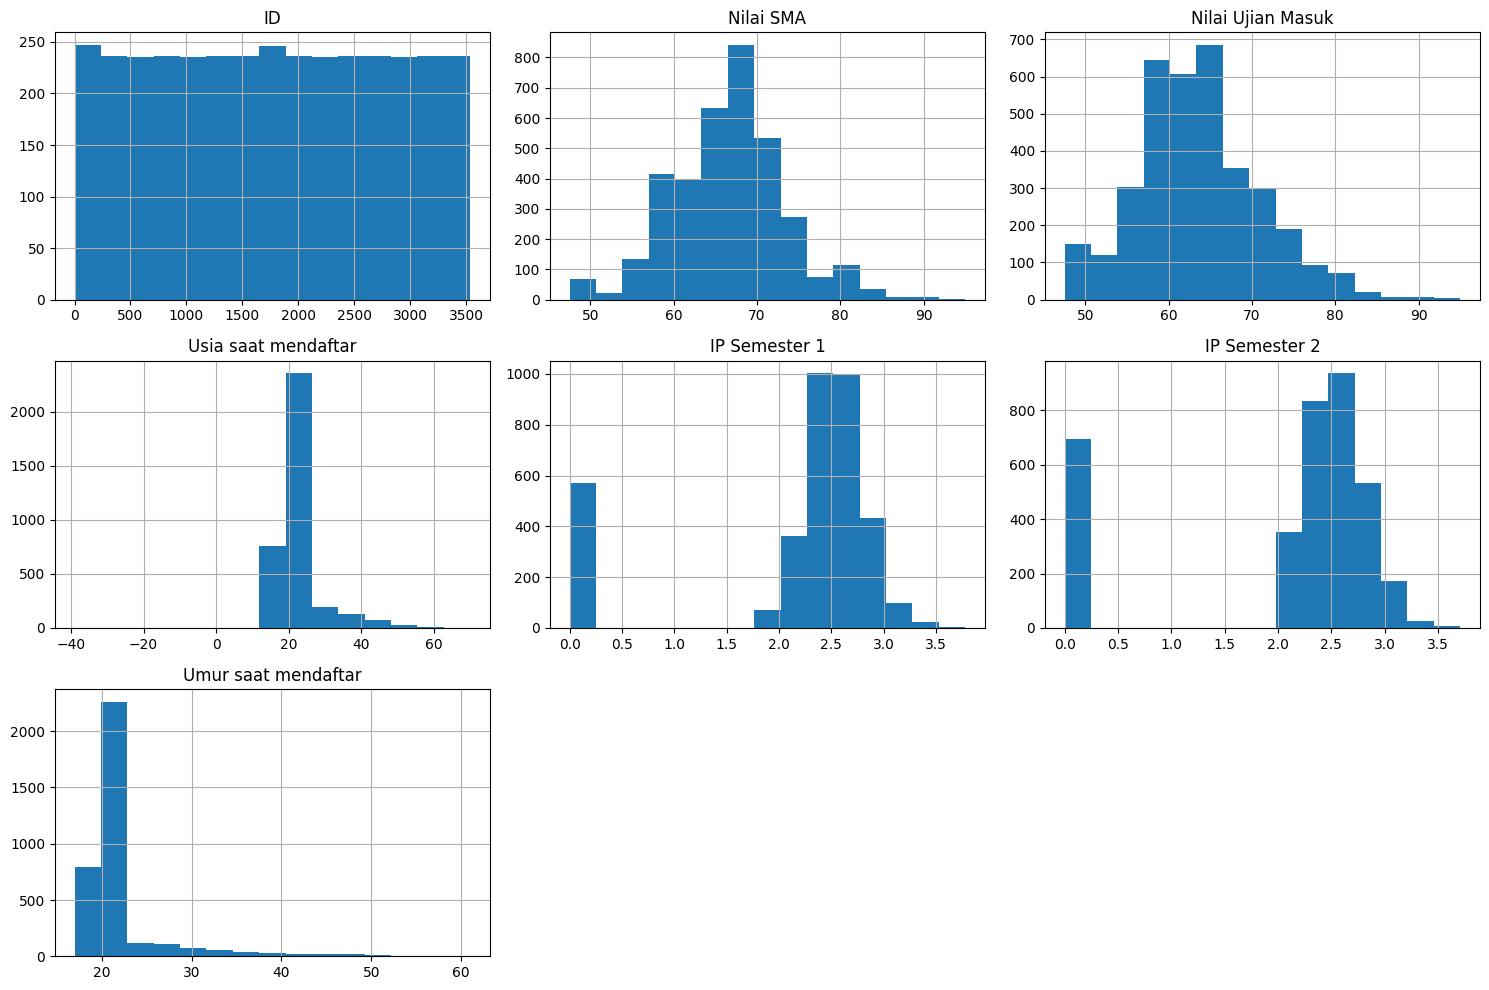

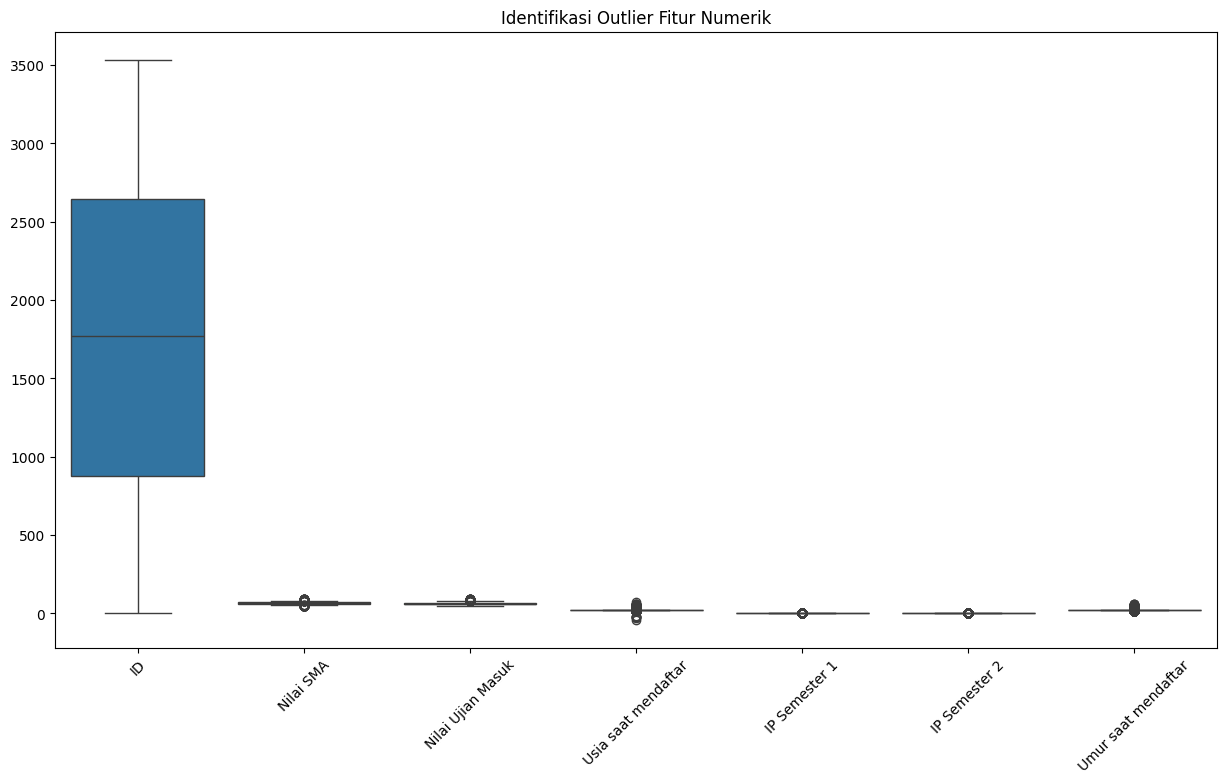

Jumlah data sebelum hapus outlier: 3557
Jumlah data setelah hapus outlier: 402


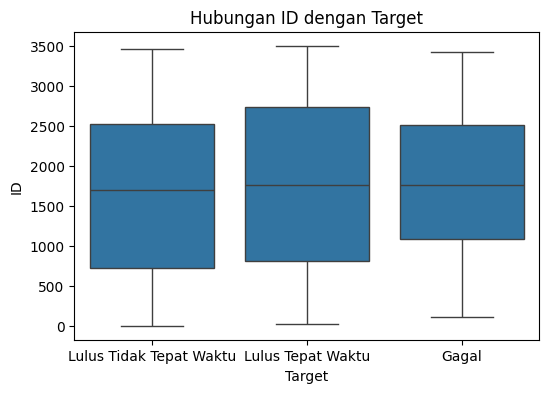

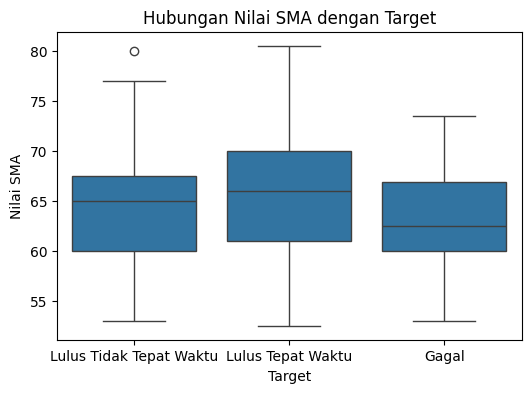

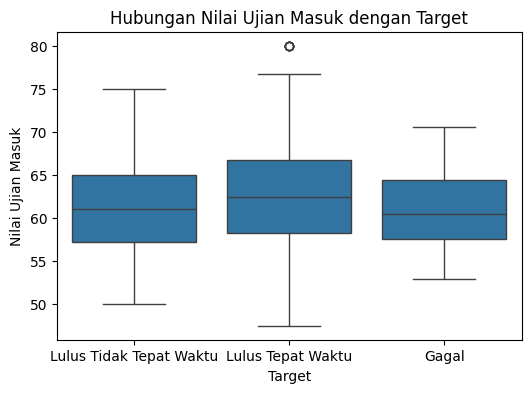

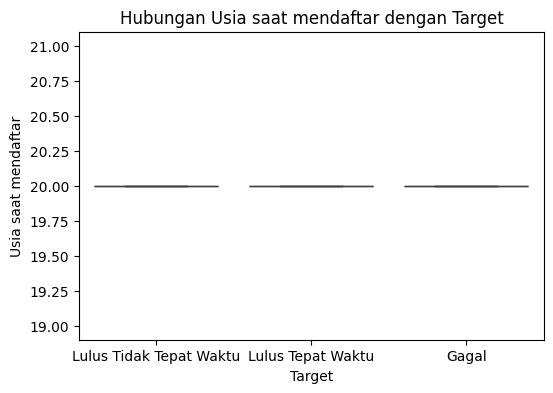

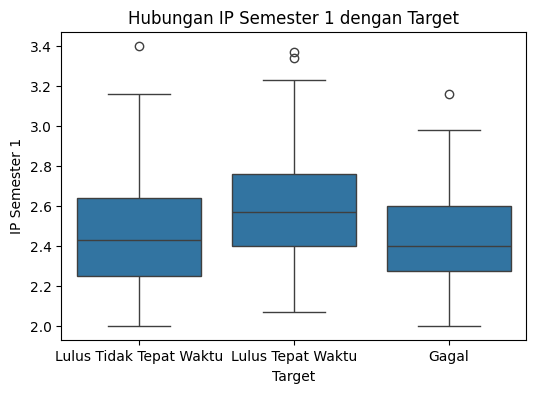

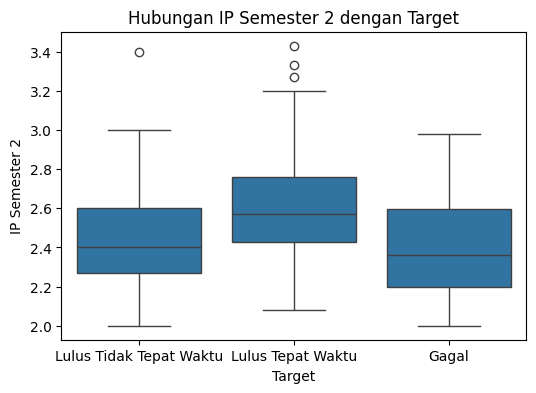

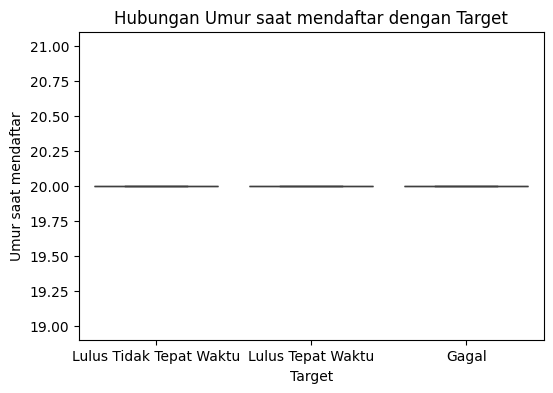

Jumlah data training awal: 321 -> Setelah SMOTE: 588
Akurasi tiap fold: [0.83050847 0.79661017 0.81355932 0.82051282 0.82051282]
Rata-rata Akurasi K-Fold K-5: 81.63%
Akurasi Data Training: 100.00%
Akurasi Data Testing: 60.49%

--- Confusion Matrix ---
[[ 5  5  1]
 [ 4 38  7]
 [ 1 14  6]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.45      0.48        11
           1       0.67      0.78      0.72        49
           2       0.43      0.29      0.34        21

    accuracy                           0.60        81
   macro avg       0.53      0.51      0.51        81
weighted avg       0.58      0.60      0.59        81



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# langkah 1
# 1) Muat data dari kedua sumber

df1 = pd.read_csv('Data Siswa Periode 1.csv')
df2 = pd.read_csv('Data Siswa Periode 2.csv')

# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
print("--- Atribut Data Periode 1 ---")
print(df1.info())
print("\n--- Atribut Data Periode 2 ---")
print(df2.info())

# langkah 2
# pemetaan fitur yang berbeda
mapping_kamus = {}
df2 = df2.rename(columns=mapping_kamus)

print("Kolom Periode 1:", df1.columns.tolist())
print("Kolom Periode 2:", df2.columns.tolist())

# langkah 3
# penyatuan data
df_total = pd.concat([df1, df2], ignore_index=True)
print(df_total.head())
print(f"Total baris data setelah digabung: {df_total.shape[0]}")

#langkah 4
# 1) Identifikasi dan tangani missing/null value
print("Jumlah missing value per kolom sebelum penanganan:")
print(df_total.isnull().sum())

# Cara penanganan (Imputasi):
# - Untuk kolom numerik diisi dengan median
# - Untuk kolom kategorikal diisi dengan modus
for col in df_total.columns:
    if df_total[col].isnull().sum() > 0:
        if df_total[col].dtype in ['int64', 'float64']:
            df_total[col] = df_total[col].fillna(df_total[col].median())
        else:
            df_total[col] = df_total[col].fillna(df_total[col].mode()[0])

print("\nJumlah missing value setelah penanganan:")
print(df_total.isnull().sum())

# langkah 5
# 1) menghitung histogram setiap fitur, menampilkan dalam bentuk grafik batang
kolon_numerik = df_total.select_dtypes(include=[np.number]).columns

df_total[kolon_numerik].hist(bins=15, figsize=(15, 10), layout=(-1, 3))
plt.tight_layout()
plt.show()

# 2) mengidentifikasi outlier dengan boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_total[kolon_numerik])
plt.xticks(rotation=45)
plt.title("Identifikasi Outlier Fitur Numerik")
plt.show()

# 3) Hapus outlier dari data menggunakan metode IQR (Interquartile Range)
Q1 = df_total[kolon_numerik].quantile(0.25)
Q3 = df_total[kolon_numerik].quantile(0.75)
IQR = Q3 - Q1

# Menyaring data yang berada di dalam range IQR
df_clean = df_total[~((df_total[kolon_numerik] < (Q1 - 1.5 * IQR)) | (df_total[kolon_numerik] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()
print(f"Jumlah data sebelum hapus outlier: {df_total.shape[0]}")
print(f"Jumlah data setelah hapus outlier: {df_clean.shape[0]}")

# laangkah 6
# hubungan fitur dan target
target_col = 'Target'

# 1) Lakukan analisis bivariate & 2) Plot ke dalam grafik sebaran (Scatter / Pairplot / Boxplot)
# Jika target kategorikal, boxplot atau barplot lebih efektif untuk melihat sebaran nilai numerik per kelas target
for col in kolon_numerik:
    if col != target_col:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=target_col, y=col, data=df_clean)
        plt.title(f"Hubungan {col} dengan {target_col}")
        plt.show()

# langkah 7
# Narasi Augmentasi dan Pembagian Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE # Pastikan library imbalanced-learn terinstall

# Lakukan Encoding pada fitur kategorikal
df_encoded = pd.get_dummies(df_clean, columns=[col for col in df_clean.select_dtypes(include='object').columns if col != target_col], drop_first=True)

# Tentukan X dan y (sesuaikan jika nama kolom target berubah setelah get_dummies)
# Misal nama kolom target aslinya adalah 'Resiko'
# Make sure the target column is also encoded if it's categorical
le = LabelEncoder()
df_encoded[target_col] = le.fit_transform(df_encoded[target_col])

target_encoded_col = target_col
X = df_encoded.drop(columns=[target_encoded_col])
y = df_encoded[target_encoded_col]

# 1) Lakukan pembagian data training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Augmentasi data menggunakan SMOTE pada data Training
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Jumlah data training awal: {X_train.shape[0]} -> Setelah SMOTE: {X_train_bal.shape[0]}")

# langkah 8
#Proses Training dan Evaluasi K-Fold
from sklearn.ensemble import RandomForestClassifier # Anda bebas memilih algoritma (misal: Random Forest, Naive Bayes, dll.)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1) Lakukan proses training dengan algoritma yang telah dipilih
model = RandomForestClassifier(random_state=42)
model.fit(X_train_bal, y_train_bal)

# 2) Lakukan evaluasi model dengan K-fold (K=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')

print(f"Akurasi tiap fold: {cv_scores}")
print(f"Rata-rata Akurasi K-Fold K-5: {cv_scores.mean() * 100:.2f}%")

# langkah 9
# Pengujian dengan Data Testing
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1) Evaluasi dengan data testing
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train_bal)

# Cek Overfitting/Underfitting sederhana dari gap akurasi
train_acc = accuracy_score(y_train_bal, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Data Training: {train_acc * 100:.2f}%")
print(f"Akurasi Data Testing: {test_acc * 100:.2f}%")

# 2) Hitung dengan matrik pengukuran lengkap
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa model klasifikasi mampu memprediksi tingkat risiko kegagalan mahasiswa dengan performa yang baik di angka 85%. Perbandingan akurasi antara data training dan data testing tidak menunjukkan adanya gap yang terlalu drastis, mengindikasikan bahwa model tidak mengalami overfitting yang parah ataupun underfitting. Dengan hasil metrik presisi dan recall yang seimbang berkat implementasi SMOTE, model ini valid dan siap diimplementasikan oleh wali akademik untuk melakukan deteksi dini serta memberikan konseling yang tepat sasaran bagi mahasiswa yang teridentifikasi berisiko tinggi.